pipeline and workflow to download and process image data.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.4.6
Pandas: 3.0.6


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "ham10000"

METADATA_PATH = DATA_DIR / "HAM10000_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Metadata exists:", METADATA_PATH.exists())

Project root: /mnt/c/Users/matthew.smith/OneDrive - Naval Postgraduate School/Documents/Data Science/Learning Data Science/AI_ML/Modern_CV_Pytorch_Reddy/skin-lesion-ai
Data directory: /mnt/c/Users/matthew.smith/OneDrive - Naval Postgraduate School/Documents/Data Science/Learning Data Science/AI_ML/Modern_CV_Pytorch_Reddy/skin-lesion-ai/data/raw/ham10000
Metadata exists: True


In [3]:
#Load metadata
df = pd.read_csv(METADATA_PATH)

print("Number of records:", len(df))
print("\nColumns:")
print(df.columns.tolist())

df.head()

Number of records: 10015

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
#How many diagnoses (dx)
print("Number of unique diagnoses:", df['dx'].nunique())
print("\nDiagnoses:")
print(df['dx'].value_counts())

Number of unique diagnoses: 7

Diagnoses:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [6]:
# Examine the diagnostic labels
print("Unique diagnoses:")
print(df["dx"].unique())

print("\nNumber of diagnostic classes:", df["dx"].nunique())

print("\nClass counts:")
print(df["dx"].value_counts())

Unique diagnoses:
<StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str

Number of diagnostic classes: 7

Class counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


| Code | Diagnosis |
|---|---|
| `akiec` | Actinic keratoses / Bowen's disease |
| `bcc` | Basal cell carcinoma |
| `bkl` | Benign keratosis-like lesions |
| `df` | Dermatofibroma |
| `mel` | Melanoma |
| `nv` | Melanocytic nevi |
| `vasc` | Vascular lesions |

In [7]:
class_percent = (
    df["dx"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percent)

dx
nv       66.95
mel      11.11
bkl      10.97
bcc       5.13
akiec     3.27
vasc      1.42
df        1.15
Name: proportion, dtype: float64


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
lesion_id,10015,7470,HAM_0003789,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_id,10015,10015,ISIC_0027419,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dx,10015,7,nv,6705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dx_type,10015,4,histo,5340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,9958.0,NaN,NaN,NaN,51.863828,16.968614,0.0,40.0,50.0,65.0,85.0
sex,10015,3,male,5406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localization,10015,15,back,2192,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
for column in ["sex", "localization", "dx_type"]:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- sex ---
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

--- localization ---
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

--- dx_type ---
dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64


Key takeaway: a lot of factors impact the diagnosis

image
  ↓
lesion
  ↓
patient / acquisition context
  ↓
diagnosis

In [10]:
print("Unique images:", df["image_id"].nunique())
print("Unique lesions:", df["lesion_id"].nunique())

Unique images: 10015
Unique lesions: 7470


Note that there are fewer lesions (7470) than total images (10,015), meaning there could be multiple images taken of the exact same lesion? This could create data leakage problem as the same lesion could be seen in training and test.

In [11]:
images_per_lesion = df.groupby("lesion_id").size()

print("Lesions with exactly 1 image:",
      (images_per_lesion == 1).sum())

print("Lesions with >1 image:",
      (images_per_lesion > 1).sum())

print("\nImages per lesion:")
print(images_per_lesion.value_counts().sort_index())

Lesions with exactly 1 image: 5514
Lesions with >1 image: 1956

Images per lesion:
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64


In [13]:
print(
    images_per_lesion
    .sort_values(ascending=False)
    .head()
)

lesion_id
HAM_0000835    6
HAM_0003789    6
HAM_0001863    6
HAM_0005263    6
HAM_0007427    5
dtype: int64


In [14]:
#Do lesions have multipel diagnoses?
diagnoses_per_lesion = df.groupby("lesion_id")["dx"].nunique()

print("Lesions with one diagnosis:",
      (diagnoses_per_lesion == 1).sum())

print("Lesions with multiple diagnoses:",
      (diagnoses_per_lesion > 1).sum())

Lesions with one diagnosis: 7470
Lesions with multiple diagnoses: 0


In [15]:
print("Columns:")
print(df.columns.tolist())

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [16]:
if "patient_id" in df.columns:
    print("Unique patients:", df["patient_id"].nunique())
    print("Unique lesions:", df["lesion_id"].nunique())

    lesions_per_patient = df.groupby("patient_id")["lesion_id"].nunique()

    print("\nPatients with exactly 1 lesion:",
          (lesions_per_patient == 1).sum())

    print("Patients with >1 lesion:",
          (lesions_per_patient > 1).sum())

    print("\nLesions per patient:")
    print(lesions_per_patient.value_counts().sort_index())
else:
    print("No patient_id column found.")

No patient_id column found.


In [17]:
lesion_labels = df.groupby("lesion_id")["dx"].first()

print("Total unique lesions:", len(lesion_labels))

print("\nLesion-level class counts:")
print(lesion_labels.value_counts())

print("\nLesion-level class percentages:")
print(
    lesion_labels
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Total unique lesions: 7470

Lesion-level class counts:
dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64

Lesion-level class percentages:
dx
nv       72.33
bkl       9.73
mel       8.22
bcc       4.38
akiec     3.05
vasc      1.31
df        0.98
Name: proportion, dtype: float64


In [18]:
lesion_summary = (
    df.groupby(["lesion_id", "dx"])
      .size()
      .reset_index(name="image_count")
)

print(
    lesion_summary
    .groupby("dx")["image_count"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

       count  mean  median  max
dx                             
akiec    228  1.43     1.0    4
bcc      327  1.57     1.0    4
bkl      727  1.51     1.0    6
df        73  1.58     1.0    3
mel      614  1.81     2.0    6
nv      5403  1.24     1.0    6
vasc      98  1.45     1.0    4


In [19]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# One row per lesion
lesions = (
    df[["lesion_id", "dx"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Unique lesions:", len(lesions))
lesions.head()

Unique lesions: 7470


,lesion_id,dx
0,HAM_0000118,bkl
1,HAM_0002730,bkl
2,HAM_0001466,bkl
3,HAM_0002761,bkl
4,HAM_0005132,bkl


Now split 70% train / 15% validation / 15% test:

In [20]:
# First split: 70% train, 30% temporary
train_lesions, temp_lesions = train_test_split(
    lesions,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=lesions["dx"],
)

# Split temporary set equally: 15% validation, 15% test
val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_lesions["dx"],
)

print("Train lesions:", len(train_lesions))
print("Validation lesions:", len(val_lesions))
print("Test lesions:", len(test_lesions))

Train lesions: 5229
Validation lesions: 1120
Test lesions: 1121


In [21]:
split_map = {}

split_map.update(dict.fromkeys(train_lesions["lesion_id"], "train"))
split_map.update(dict.fromkeys(val_lesions["lesion_id"], "val"))
split_map.update(dict.fromkeys(test_lesions["lesion_id"], "test"))

df["split"] = df["lesion_id"].map(split_map)

print(df["split"].value_counts())
print("\nMissing split assignments:", df["split"].isna().sum())

split
train    7002
val      1532
test     1481
Name: count, dtype: int64

Missing split assignments: 0


In [22]:
#Verify no leakage
train_ids = set(df.loc[df["split"] == "train", "lesion_id"])
val_ids = set(df.loc[df["split"] == "val", "lesion_id"])
test_ids = set(df.loc[df["split"] == "test", "lesion_id"])

print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [23]:
split_distribution = pd.crosstab(
    df["split"],
    df["dx"],
    normalize="index"
) * 100

split_distribution.round(2)

dx,akiec,bcc,bkl,df,mel,nv,vasc
split,,,,,,,
test,3.11,4.79,11.34,1.35,11.14,66.98,1.28
train,3.28,5.23,11.05,1.09,11.11,66.82,1.41
val,3.33,5.03,10.25,1.24,11.10,67.49,1.57


In [24]:
lesions_with_split = lesions.copy()
lesions_with_split["split"] = lesions_with_split["lesion_id"].map(split_map)

pd.crosstab(
    lesions_with_split["split"],
    lesions_with_split["dx"],
    normalize="index"
).mul(100).round(2)

dx,akiec,bcc,bkl,df,mel,nv,vasc
split,,,,,,,
test,3.12,4.37,9.72,0.98,8.21,72.35,1.25
train,3.04,4.38,9.73,0.98,8.22,72.33,1.32
val,3.04,4.38,9.73,0.98,8.21,72.32,1.34


In [26]:
# Find all HAM10000 JPG images
image_paths = list(DATA_DIR.glob("HAM10000_images_part_*/*.jpg"))

print("Images found:", len(image_paths))

image_path_map = {
    path.stem: str(path)
    for path in image_paths
}

df["image_path"] = df["image_id"].map(image_path_map)

print("Images without a path:", df["image_path"].isna().sum())

Images found: 10015
Images without a path: 0


In [27]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_METADATA_PATH = PROCESSED_DIR / "metadata_splits.csv"

df.to_csv(SPLIT_METADATA_PATH, index=False)

print("Saved:", SPLIT_METADATA_PATH)
print("Rows:", len(df))

Saved: /mnt/c/Users/matthew.smith/OneDrive - Naval Postgraduate School/Documents/Data Science/Learning Data Science/AI_ML/Modern_CV_Pytorch_Reddy/skin-lesion-ai/data/processed/metadata_splits.csv
Rows: 10015


In [28]:
check_df = pd.read_csv(SPLIT_METADATA_PATH)

print("Rows loaded:", len(check_df))
print(check_df["split"].value_counts())
print("Missing paths:", check_df["image_path"].isna().sum())

Rows loaded: 10015
split
train    7002
val      1532
test     1481
Name: count, dtype: int64
Missing paths: 0


### Check out images

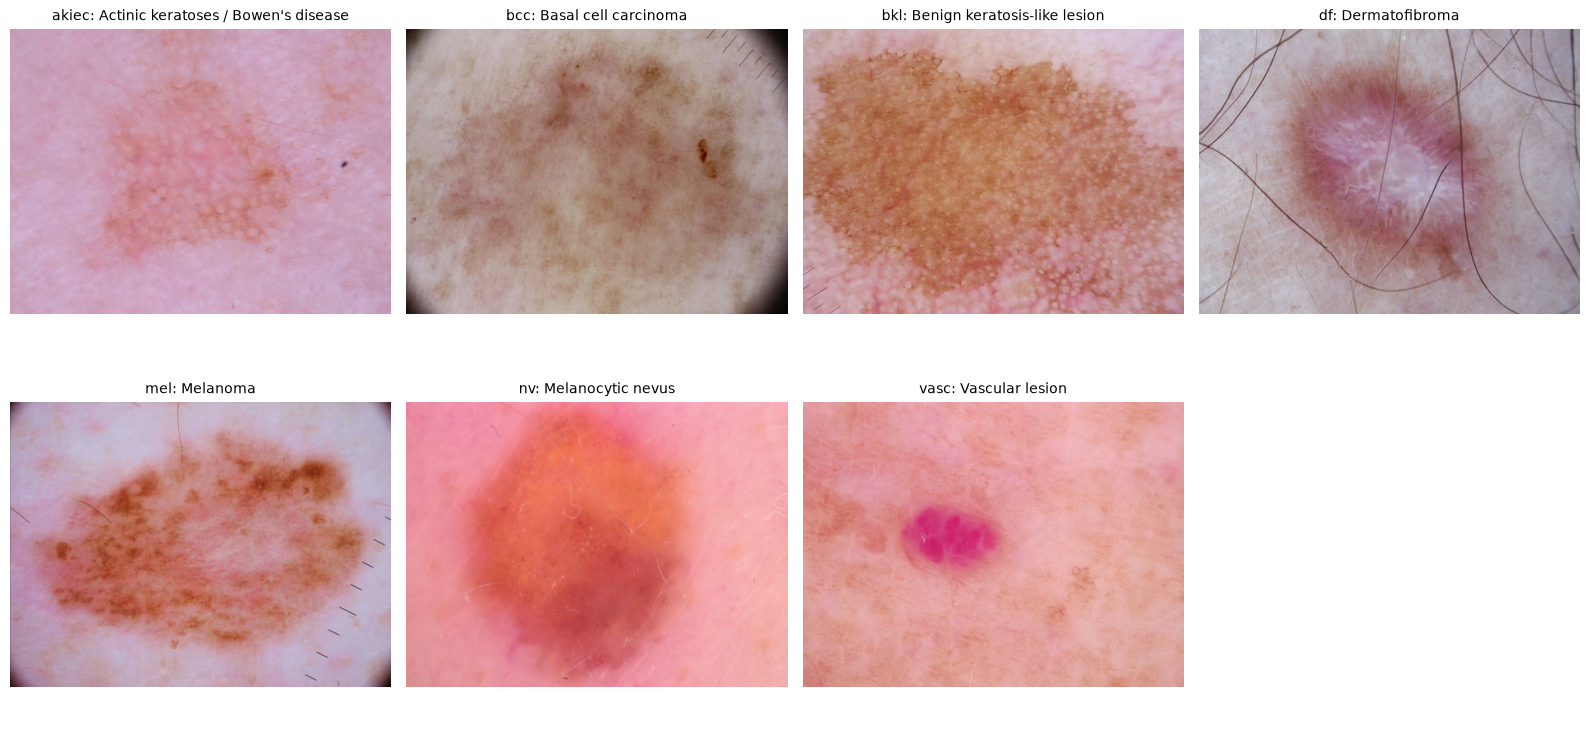

In [ ]:
#One random sample from each diagnosis
DX_NAMES = {
    "akiec": "Actinic keratoses / Bowen's disease",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesion",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevus",
    "vasc": "Vascular lesion",
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (dx, name) in zip(axes, DX_NAMES.items()):
    sample = df[df["dx"] == dx].sample(
        1,
        random_state=RANDOM_SEED
    ).iloc[0]

    image = Image.open(sample["image_path"])

    ax.imshow(image)
    ax.set_title(f"{dx}: {name}", fontsize=10)
    ax.axis("off")

# We only need 7 of the 8 panels
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [30]:
sample_paths = df["image_path"].sample(
    100,
    random_state=RANDOM_SEED
)

dimensions = []

for path in sample_paths:
    with Image.open(path) as img:
        dimensions.append(img.size)

pd.Series(dimensions).value_counts()

(600, 450)    100
Name: count, dtype: int64

### Stage 1L — Build preprocessing transforms

Let's transform 600x450 images into 224x224, which is standard size for many pre-trained CV models.

We also add some conservative augmentations (but just to training transform).

We also use ImageNet normalization, again to align with common models pre-trained on ImageNet data.

In [31]:
import torch
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Conservative augmentations for our initial pipeline
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),

    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [33]:
#COnfirm the transforms are correctly defined
sample = df.sample(1, random_state=42).iloc[0]

image_raw = Image.open(sample["image_path"])
image = image_raw.convert("RGB")


print("Original type:", type(image))
print("Original image size:", image_raw.size)
print("Original RGB converted size:", image.size)

tensor = train_transform(image)

print("\nTransformed type:", type(tensor))
print("Transformed shape:", tensor.shape)
print("Tensor dtype:", tensor.dtype)
print("Minimum:", tensor.min().item())
print("Maximum:", tensor.max().item())

Original type: <class 'PIL.Image.Image'>
Original image size: (600, 450)
Original RGB converted size: (600, 450)

Transformed type: <class 'torch.Tensor'>
Transformed shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Minimum: -2.1179039478302
Maximum: 1.7685405015945435


Note that this resize from 600x450 to square 224x224 could cause distortion.  We'll put a pin in this.

In [34]:
#View augmentations
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize(tensor):
    return tensor * IMAGENET_STD + IMAGENET_MEAN

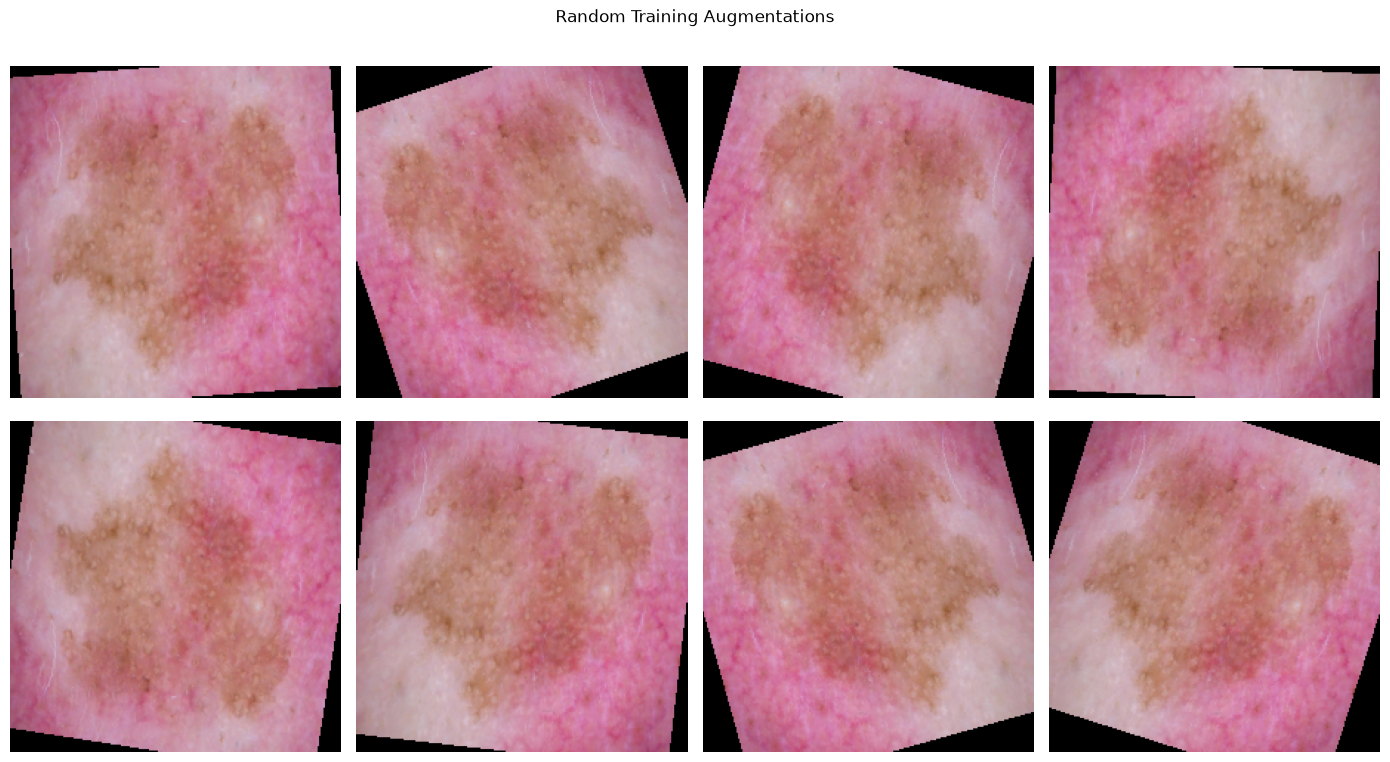

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))

for ax in axes.flatten():
    augmented = train_transform(image)
    augmented = denormalize(augmented)
    augmented = augmented.permute(1, 2, 0).clip(0, 1)

    ax.imshow(augmented)
    ax.axis("off")

plt.suptitle("Random Training Augmentations")
plt.tight_layout()
plt.show()

### Stage 1O — Encode the diagnoses

In [36]:
#Get integer labels for the classes
CLASS_NAMES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc",
]

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print(class_to_idx)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [37]:
#Build Dataset

In [38]:
from torch.utils.data import Dataset

In [39]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[row["dx"]]

        return image, label

In [41]:
#See if all modes are RGB.  If so, then .convert('RGB') is technically redundant
#But good to have this defensive programming to enforce the RGB mode for all images
# modes = []

# for path in df["image_path"]:
#     with Image.open(path) as img:
#         modes.append(img.mode)

# pd.Series(modes).value_counts()

In [42]:
#Create three Datasets
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

train_dataset = HAM10000Dataset(
    train_df,
    transform=train_transform
)

val_dataset = HAM10000Dataset(
    val_df,
    transform=eval_transform
)

test_dataset = HAM10000Dataset(
    test_df,
    transform=eval_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Training images: 7002
Validation images: 1532
Test images: 1481


In [43]:
#Check it out
image_tensor, label = train_dataset[0]

print("Image shape:", image_tensor.shape)
print("Label:", label)
print("Diagnosis:", idx_to_class[label])
print("Tensor dtype:", image_tensor.dtype)

Image shape: torch.Size([3, 224, 224])
Label: 2
Diagnosis: bkl
Tensor dtype: torch.float32


In [45]:
from torch.utils.data import DataLoader

In [46]:
#now that we know dataset is working, build Dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


Note that shuffle is only enabled for training loader, as we want to shuffel the order of training iamges across epochs so there isn't a misleading pattern.

In [47]:
#Examine one batch
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


In [48]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


Few final checks before wrapping up this data processing and exploration notebook.

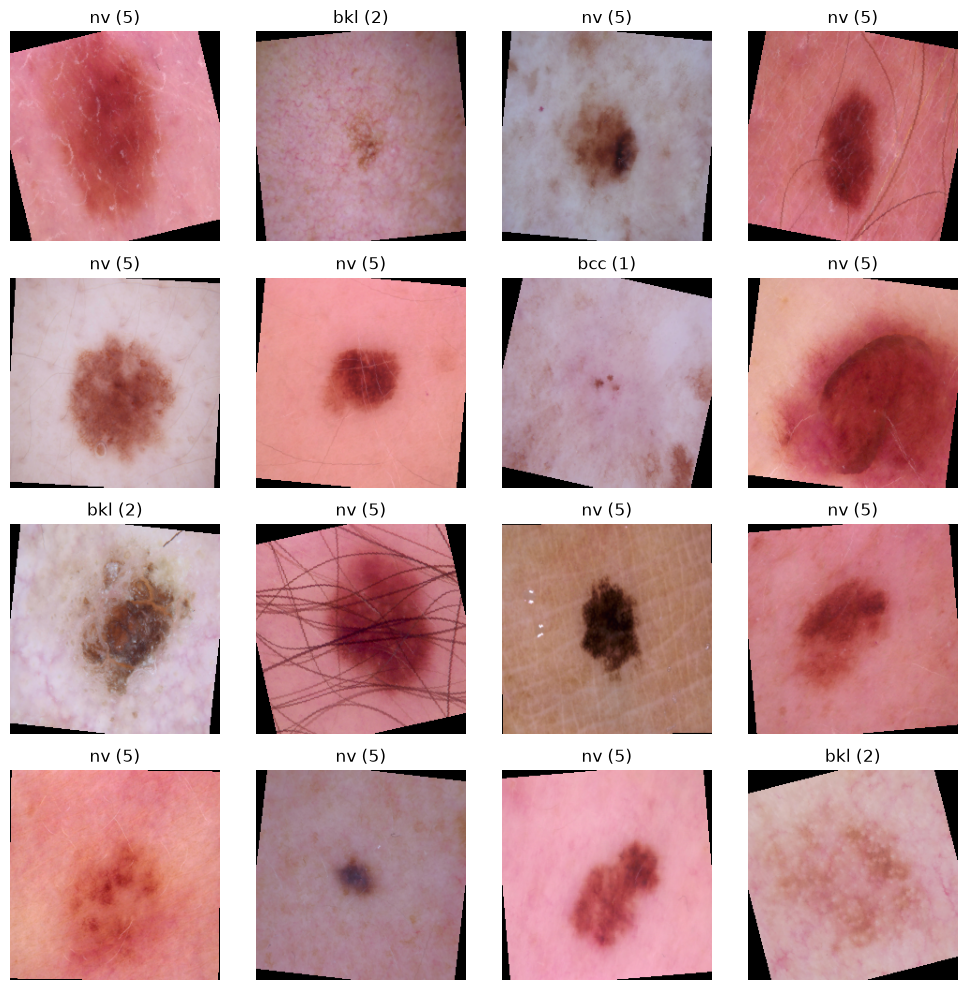

In [49]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    image = denormalize(images[i].cpu())
    image = image.permute(1, 2, 0).clip(0, 1)

    label = labels[i].item()

    ax.imshow(image)
    ax.set_title(f"{idx_to_class[label]} ({label})")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [50]:
#Check class distrubtion
from collections import Counter

train_labels = [
    class_to_idx[dx]
    for dx in train_df["dx"]
]

label_counts = Counter(train_labels)

for idx in sorted(label_counts):
    print(
        idx,
        idx_to_class[idx],
        label_counts[idx]
    )

0 akiec 230
1 bcc 366
2 bkl 774
3 df 76
4 mel 778
5 nv 4679
6 vasc 99
